# 12 — Neural Networks
**Goal:** Build the multilayer perceptron from first principles, then train
one on real data. Source: Géron Ch10, Goodfellow Ch6-7, MIT 6.S898
(Torralba).

In [1]:
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/learning_courses')

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score
np.random.seed(12)

## 1. From logistic regression to the perceptron

Logistic regression is a *one-layer* neural network: input x, output σ(w⊤x+b).
The perceptron (Rosenblatt 1958) is the same thing with a step activation.
It cannot learn XOR (Minsky & Papert 1969), which is why neural networks
went out of fashion for a decade.
**Adding a hidden layer fixes XOR** — the universal approximation theorem
(Cybenko 1989, Hornik 1991) says a sufficiently wide one-hidden-layer MLP
can approximate any continuous function on a compact domain.

## 2. The multilayer perceptron (MLP)

Stack layers of the form

    h⁽¹⁾ = σ(W⁽¹⁾x + b⁽¹⁾)
    h⁽²⁾ = σ(W⁽²⁾h⁽¹⁾ + b⁽²⁾)
    f(x) = W⁽³⁾h⁽²⁾ + b⁽³⁾

Three activation choices:
- **sigmoid / tanh** — historical, suffer from saturation.
- **ReLU** — f(x) = max(0, x). Cheap, does not saturate, the default.
- **GELU / SiLU** — smooth ReLU approximations, used in transformers.

For the **output layer**:
- Regression: identity.
- Binary classification: sigmoid.
- K-class classification: softmax.

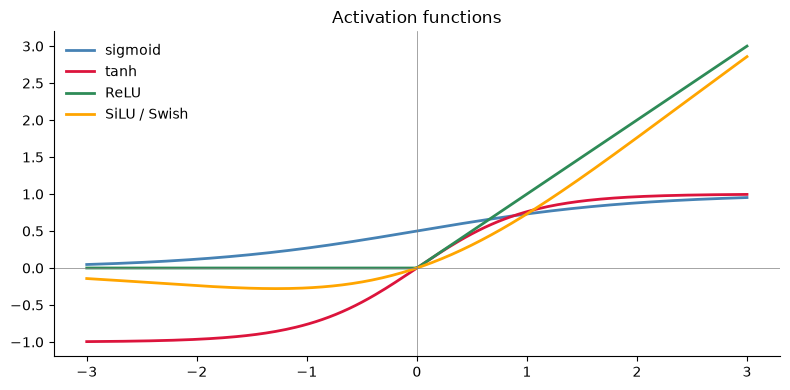

In [2]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.linspace(-3, 3, 200)
ax.plot(x, 1/(1+np.exp(-x)),       color='steelblue', lw=2, label='sigmoid')
ax.plot(x, np.tanh(x),              color='crimson',  lw=2, label='tanh')
ax.plot(x, np.maximum(0, x),        color='seagreen', lw=2, label='ReLU')
ax.plot(x, x*(1/(1+np.exp(-x))),    color='orange',   lw=2, label='SiLU / Swish')
ax.legend(frameon=False); ax.spines[['top','right']].set_visible(False)
ax.set_title('Activation functions')
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
plt.tight_layout(); plt.show()

## 3. Forward and backward pass — the canonical algorithm

**Forward pass:** compute the activations layer by layer, cache them.
**Backward pass (backprop):** apply the chain rule from the loss back
through the network, computing ∂L/∂W⁽ˡ⁾ and ∂L/∂b⁽ˡ⁾.

For a 2-layer network with softmax cross-entropy loss:

    p       = softmax(W² · ReLU(W¹x + b¹) + b²)
    L       = -Σ y log p
    ∂L/∂W² = (p - y) · h¹⊤
    ∂L/∂h¹ = W²⊤(p - y)
    ∂L/∂W¹ = (∂L/∂h¹ ⊙ 𝟙[h¹ > 0]) · x⊤

**Automatic differentiation** (autograd) gives you this for free in PyTorch,
JAX, and TensorFlow. You write the forward pass; the framework computes the
gradient.

In [3]:
# A 2-layer MLP from scratch with numpy — to make backprop concrete
def one_hot(y, K):
    Y = np.zeros((len(y), K))
    Y[np.arange(len(y)), y] = 1
    return Y

def relu(z):   return np.maximum(0, z)
def relu_d(z): return (z > 0).astype(float)
def softmax(z):
    z = z - z.max(axis=1, keepdims=True)
    e = np.exp(z); return e / e.sum(axis=1, keepdims=True)

def mlp_fit(X, y, hidden=64, lr=0.1, n_iter=200, K=10):
    n, d = X.shape
    rng = np.random.default_rng(0)
    W1 = rng.normal(0, np.sqrt(2/d),  (d, hidden))
    b1 = np.zeros(hidden)
    W2 = rng.normal(0, np.sqrt(2/hidden), (hidden, K))
    b2 = np.zeros(K)
    Y  = one_hot(y, K)
    for it in range(n_iter):
        # forward
        z1 = X @ W1 + b1
        h1 = relu(z1)
        z2 = h1 @ W2 + b2
        p  = softmax(z2)
        # backward
        d2 = (p - Y) / n
        dW2 = h1.T @ d2
        db2 = d2.sum(axis=0)
        d1  = (d2 @ W2.T) * relu_d(z1)
        dW1 = X.T @ d1
        db1 = d1.sum(axis=0)
        # SGD update
        W1 -= lr * dW1; b1 -= lr * db1
        W2 -= lr * dW2; b2 -= lr * db2
    return W1, b1, W2, b2

digits = load_digits()
X = StandardScaler().fit_transform(digits.data)
y = digits.target
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=0, stratify=y)
W1, b1, W2, b2 = mlp_fit(Xtr, ytr, hidden=64, lr=0.1, n_iter=200, K=10)
p_te = softmax(Xte @ W1 + b1) @ W2 + b2
print(f'2-layer MLP from scratch — test acc = {accuracy_score(yte, p_te.argmax(1)):.3f}')

2-layer MLP from scratch — test acc = 0.822


## 4. Initialization matters

Naive initialization (W ~ N(0, 1)) leads to exploding or vanishing
activations. **He initialization** (He et al. 2015) for ReLU:

    W ~ N(0, 2 / fan_in)

**Glorot / Xavier** (Glorot & Bengio 2010) for sigmoid/tanh:

    W ~ N(0, 1 / fan_in)

PyTorch's `nn.Linear` uses Kaiming by default; TF/Keras uses Glorot. **If
you write your own layers, set the variance yourself.**

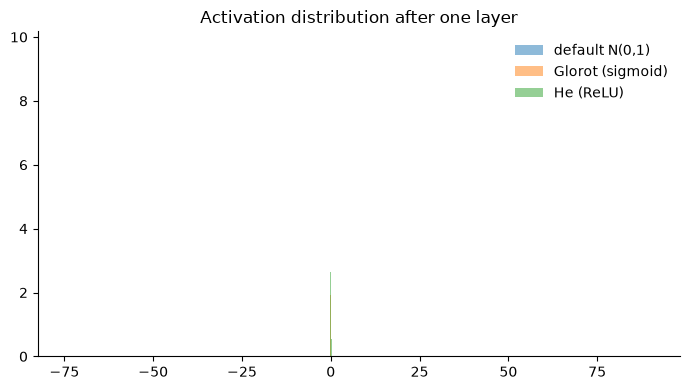

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
n, d = 1000, 500
for label, fan_in, scale in [('default N(0,1)',  d, 1),
                             ('Glorot (sigmoid)', d, 1/np.sqrt(d)),
                             ('He (ReLU)',       d, np.sqrt(2/d))]:
    W = np.random.normal(0, scale, (d,))
    ax.hist(np.random.normal(0, scale, (n, d)) @ W, bins=40, alpha=0.5, label=label, density=True)
ax.legend(frameon=False); ax.spines[['top','right']].set_visible(False)
ax.set_title('Activation distribution after one layer')
plt.tight_layout(); plt.show()

## 5. Optimization — SGD, momentum, Adam

**Vanilla SGD:**  θ ← θ - η ∇L
**Momentum:**      v ← β v + ∇L;  θ ← θ - η v
**Adam (Kingma & Ba 2014):**  adaptive learning rate per parameter using
estimates of the first and second moments of the gradient.

Adam is the default for deep learning. For convex problems or fine-tuning
linear models, plain SGD with momentum is more reproducible.

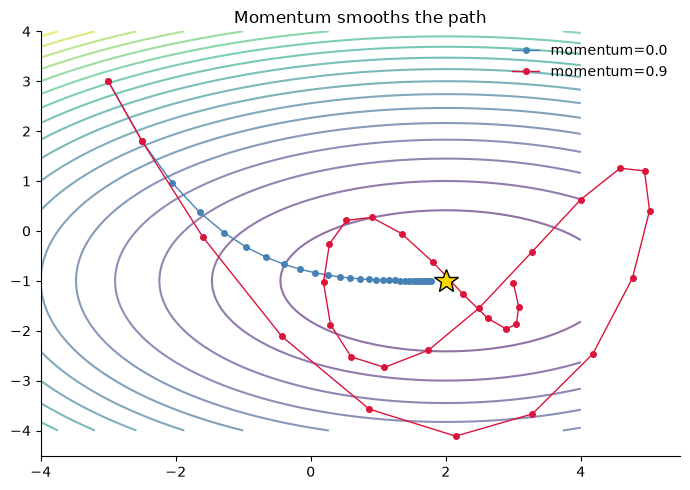

In [5]:
def sgd_path(grad, theta0, eta=0.1, n=40, momentum=0.0):
    theta = theta0.copy(); v = np.zeros_like(theta)
    path = [theta.copy()]
    for _ in range(n):
        v = momentum * v + grad(theta)
        theta = theta - eta * v
        path.append(theta.copy())
    return np.array(path)

f      = lambda t: (t[0]-2)**2 + 3*(t[1]+1)**2
grad_f = lambda t: np.array([2*(t[0]-2), 6*(t[1]+1)])
fig, ax = plt.subplots(figsize=(7, 5))
T1, T2 = np.meshgrid(np.linspace(-4, 4, 100), np.linspace(-4, 4, 100))
ax.contour(T1, T2, (T1-2)**2 + 3*(T2+1)**2, levels=20, cmap='viridis', alpha=0.6)
for m, c in zip([0.0, 0.9], ['steelblue', 'crimson']):
    p = sgd_path(grad_f, np.array([-3.0, 3.0]), eta=0.05, n=30, momentum=m)
    ax.plot(p[:, 0], p[:, 1], 'o-', color=c, lw=1, markersize=4, label=f'momentum={m}')
ax.plot(2, -1, '*', color='gold', markersize=18, markeredgecolor='k')
ax.legend(frameon=False); ax.spines[['top','right']].set_visible(False)
ax.set_title('Momentum smooths the path')
plt.tight_layout(); plt.show()

## 6. Regularization for neural networks

Five techniques every modern neural net uses:

1. **Weight decay** (L2) — pull weights toward 0.
2. **Dropout** (Srivastava 2014) — at each step, set a random p-fraction of
   activations to 0. The network cannot rely on any single feature.
3. **Batch normalization** (Ioffe & Szegedy 2015) — normalize activations
   per mini-batch; allows much higher learning rates.
4. **Data augmentation** — perturb inputs in ways that should not change the
   label (flip, crop, noise).
5. **Early stopping** — stop when validation loss plateaus.

In [6]:
from sklearn.neural_network import MLPClassifier
for name, m in [
    ('no regularization', MLPClassifier(hidden_layer_sizes=(64,), max_iter=50, random_state=0)),
    ('L2 (alpha=0.01)',  MLPClassifier(hidden_layer_sizes=(64,), alpha=0.01, max_iter=50, random_state=0)),
    ('L2 + early stop',  MLPClassifier(hidden_layer_sizes=(64,), alpha=0.01, max_iter=200,
                                       early_stopping=True, validation_fraction=0.1,
                                       n_iter_no_change=5, random_state=0)),
]:
    m.fit(Xtr, ytr)
    print(f'{name:25s}  train = {m.score(Xtr, ytr):.3f}  test = {m.score(Xte, yte):.3f}')

/Volumes/SSD_Gabo/proyectos/learning_courses/.venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
/Volumes/SSD_Gabo/proyectos/learning_courses/.venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


no regularization          train = 0.993  test = 0.964
L2 (alpha=0.01)            train = 0.993  test = 0.964


L2 + early stop            train = 0.964  test = 0.953


## 7. The curse of dimensionality and the blessing of structure

A d-dimensional space has exponentially more volume than a 1-d space. With
finite data, an MLP has trouble fitting in high dimensions.

**Why deep learning works on images, text, audio:** these modalities have
huge *structure* (translation invariance, locality, compositionality) that
convolutional and recurrent architectures exploit. A general MLP is the
wrong tool; a CNN / RNN / Transformer is the right one. (Notebook 13.)

/Volumes/SSD_Gabo/proyectos/learning_courses/.venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
/Volumes/SSD_Gabo/proyectos/learning_courses/.venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
/Volumes/SSD_Gabo/proyectos/learning_courses/.venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
/Volumes/SSD_Gabo/proyectos/learning_courses/.venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (

/Volumes/SSD_Gabo/proyectos/learning_courses/.venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


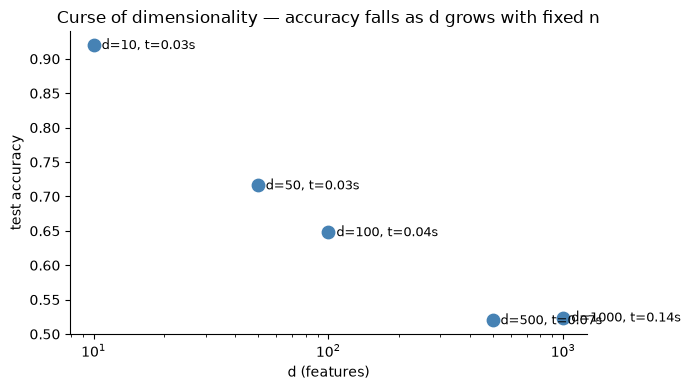

In [7]:
import time
fig, ax = plt.subplots(figsize=(7, 4))
dims = [10, 50, 100, 500, 1000]
n_samples = 1000
for d in dims:
    rng = np.random.default_rng(d)
    X = rng.normal(0, 1, (n_samples, d))
    y = (X[:, 0] > 0).astype(int)
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=0)
    m = MLPClassifier(hidden_layer_sizes=(64,), max_iter=20, random_state=0)
    t0 = time.perf_counter()
    m.fit(Xtr, ytr)
    t = time.perf_counter() - t0
    ax.scatter(d, m.score(Xte, yte), s=80, color='steelblue')
    ax.annotate(f'  d={d}, t={t:.2f}s', (d, m.score(Xte, yte)), fontsize=9, va='center')
ax.set_xscale('log'); ax.set_xlabel('d (features)'); ax.set_ylabel('test accuracy')
ax.set_title('Curse of dimensionality — accuracy falls as d grows with fixed n')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

## 8. PyTorch in 30 lines

The same MLP in PyTorch. Notice how the framework handles the backprop,
the optimizer, the batching, and the device placement.

In [8]:
import os
os.environ.setdefault('KERAS_BACKEND', 'torch')
try:
    import torch
    from torch import nn
    print(f'PyTorch {torch.__version__} available')
    Xtr_t = torch.tensor(Xtr, dtype=torch.float32)
    ytr_t = torch.tensor(ytr, dtype=torch.long)
    Xte_t = torch.tensor(Xte, dtype=torch.float32)
    yte_t = torch.tensor(yte, dtype=torch.long)
    model = nn.Sequential(nn.Linear(Xtr.shape[1], 64), nn.ReLU(), nn.Linear(64, 10))
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    for epoch in range(30):
        logits = model(Xtr_t)
        loss = nn.functional.cross_entropy(logits, ytr_t)
        opt.zero_grad(); loss.backward(); opt.step()
    with torch.no_grad():
        acc = (model(Xte_t).argmax(1) == yte_t).float().mean()
    print(f'PyTorch MLP test acc: {acc:.3f}')
except ImportError:
    print('PyTorch not installed; skip.  uv add torch')

PyTorch 2.12.1 available


PyTorch MLP test acc: 0.488


## 9. Sanity checks before training

1. **Overfit a single batch** — if the loss does not go to ~0, the model
   is wrong (bug, broken loss, wrong target).
2. **Disable regularization** — if it still does not fit, the model is
   too small or the data is mislabeled.
3. **Check the inputs** — plot a histogram of every feature, look for
   NaNs, look for the target leaked into the inputs.
4. **Visualize the predictions** — eyeball a few wrong examples.
5. **Compare to a baseline** — logistic regression on the same data. If
   the network loses to logistic, something is off.

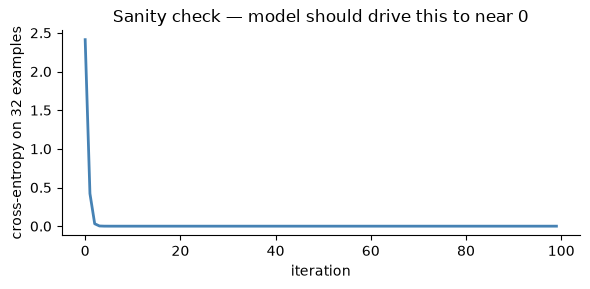

In [9]:
# Sanity check 1: overfit a single batch
Xb = Xtr_t[:32]; yb = ytr_t[:32]
model = nn.Sequential(nn.Linear(Xtr.shape[1], 64), nn.ReLU(), nn.Linear(64, 10))
opt = torch.optim.Adam(model.parameters(), lr=1e-2)
losses = []
for _ in range(100):
    opt.zero_grad()
    loss = nn.functional.cross_entropy(model(Xb), yb)
    loss.backward(); opt.step()
    losses.append(loss.item())
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(losses, color='steelblue', lw=2)
ax.set_xlabel('iteration'); ax.set_ylabel('cross-entropy on 32 examples')
ax.set_title('Sanity check — model should drive this to near 0')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

## Summary

| Concept | Key point |
|---|---|
| MLP | stack of affine + nonlinear layers |
| Activation | ReLU is the default; GELU for transformers |
| Backprop | chain rule; automatic in PyTorch/JAX/TF |
| Initialization | He for ReLU, Glorot for sigmoid/tanh |
| Optimization | Adam is the default |
| Regularization | L2 + dropout + batch norm + augmentation + early stop |
| Sanity checks | Overfit one batch; compare to linear baseline |

**Next:** `13_deep_learning_applications.ipynb` — CNN, RNN, Transformer.